In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

def find_uploaded_image(keyword, fallback_index):
  matches = [
      name for name in uploaded_names
      if keyword.lower() in name.lower()
  ]

  if matches:
    return '/content/' + matches[0]

  if fallback_index < len(uploaded_names):
    return '/content/' + uploaded_names[fallback_index]
  raise FileNotFoundError(f'Image Not Found: {keyword}')

shape_path = find_uploaded_image('shape', 0)
small_test_path = find_uploaded_image('small-connected-test', 1)

print('Input Images Loaded:')
print(shape_path)
print(small_test_path)

Saving shapes.png to shapes (1).png
Saving small-connected-test.png to small-connected-test (1).png
Input Images Loaded:
/content/shapes (1).png
/content/small-connected-test (1).png


In [4]:
shapes_image = cv2.imread(shape_path, cv2.IMREAD_GRAYSCALE)
if shapes_image is None:
  raise ValueError(f'Failed To Load Image: {shape_path}')

_, shape_binary = cv2.threshold(shapes_image, 127, 255, cv2.THRESH_BINARY)

num_labels, labels = cv2.connectedComponents(shape_binary)

max_label = max(int(np.max(labels)), 1)
label_hue = np.uint8(179 * labels / np.max(labels))
blank = 255 * np.ones_like(shape_binary)
labeled_image = cv2.merge([label_hue, blank, blank])

labeled_image = cv2.cvtColor(labeled_image, cv2.COLOR_HSV2BGR)
labeled_image[label_hue == 0] = 0

print('Number Of Labels Including Background:', num_labels)
print('Number Of Connected Components:', num_labels - 1)

Number Of Labels Including Background: 7
Number Of Connected Components: 6


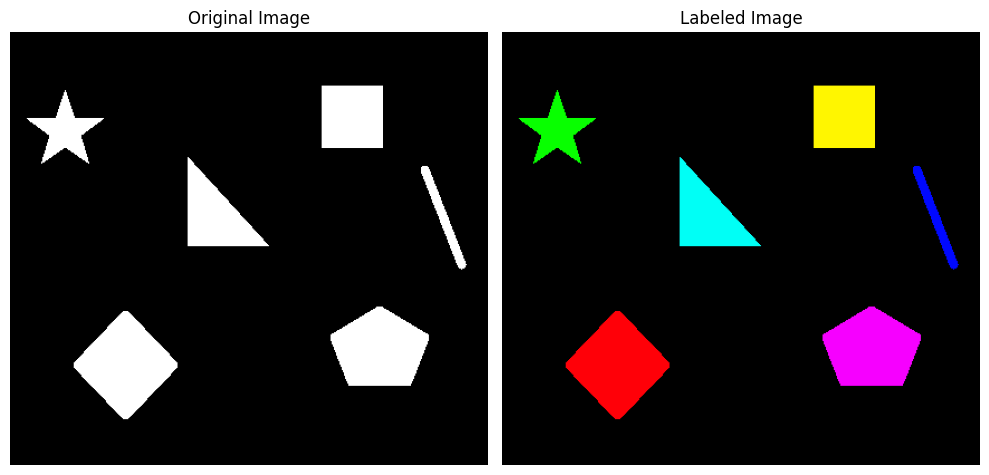

In [5]:
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(shapes_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(labeled_image, cv2.COLOR_BGR2RGB))
plt.title('Labeled Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
small_test_image = cv2.imread(small_test_path, cv2.IMREAD_GRAYSCALE)

if small_test_image is None:
  raise ValueError(f'Failed To Load Image: {small_test_path}')

_, small_test_binary = cv2.threshold(small_test_image, 127, 255, cv2.THRESH_BINARY)

num_labels_4, labels_4 = cv2.connectedComponents(small_test_binary, connectivity=4)

num_labels_8, labels_8 = cv2.connectedComponents(small_test_binary, connectivity=8)

max_label_4 = max(int(np.max(labels_4)), 1)
label_hue_4 = np.uint8(179 * labels_4 / labels_4)

max_label_8 = max(int(np.max(labels_8)), 1)
label_hue_8 = np.uint8(179 * labels_8 / labels_8)

blank = 255 * np.ones_like(small_test_binary)
labeled_image_4 = cv2.merge([label_hue_4, blank, blank])
labeled_image_8 = cv2.merge([label_hue_8, blank, blank])

labeled_image_4 = cv2.cvtColor(labeled_image_4, cv2.COLOR_HSV2BGR)
labeled_image_8 = cv2.cvtColor(labeled_image_8, cv2.COLOR_HSV2BGR)

labeled_image_4[label_hue_4 == 0] = 0
labeled_image_8[label_hue_8 == 0] = 0

print('4-Connectivity Components:', num_labels_4 - 1)
print('8-Connectivity Components:', num_labels_8 - 1)

4-Connectivity Components: 3
8-Connectivity Components: 1


/tmp/ipykernel_4790/3904680272.py:13: RuntimeWarning: invalid value encountered in divide
  label_hue_4 = np.uint8(179 * labels_4 / labels_4)
/tmp/ipykernel_4790/3904680272.py:13: RuntimeWarning: invalid value encountered in cast
  label_hue_4 = np.uint8(179 * labels_4 / labels_4)
/tmp/ipykernel_4790/3904680272.py:16: RuntimeWarning: invalid value encountered in divide
  label_hue_8 = np.uint8(179 * labels_8 / labels_8)
/tmp/ipykernel_4790/3904680272.py:16: RuntimeWarning: invalid value encountered in cast
  label_hue_8 = np.uint8(179 * labels_8 / labels_8)


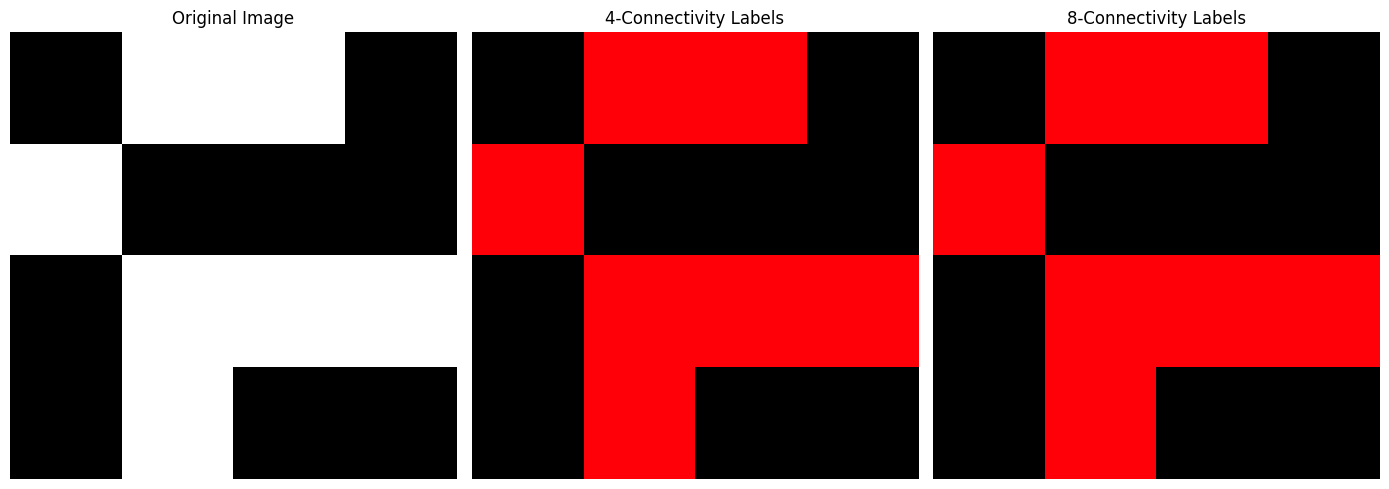

In [7]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 3, 1)
plt.imshow(small_test_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(labeled_image_4, cv2.COLOR_BGR2RGB))
plt.title('4-Connectivity Labels')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(labeled_image_8, cv2.COLOR_BGR2RGB))
plt.title('8-Connectivity Labels')
plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
output_images = {
    'shapes_labeled.png': labeled_image,
    'small_test_4_connectivity.png': labeled_image_4,
    'small_test_8_connectivity.png': labeled_image_8,
}

for filename, output_image in output_images.items():
  output_path = '/content/' + filename
  cv2.imwrite(output_path, output_image)
  print(f'Saved Image: {output_path}')
  files.download(output_path)
  print(f'Downloaded Image: {output_path}')

Saved Image: /content/shapes_labeled.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded Image: /content/shapes_labeled.png
Saved Image: /content/small_test_4_connectivity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded Image: /content/small_test_4_connectivity.png
Saved Image: /content/small_test_8_connectivity.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded Image: /content/small_test_8_connectivity.png
